# 03 â€” Simulation Runs

**Goal:** Run all 5 disruption scenarios, visualise cascading propagation, and compare damage.

**Scenarios:**
1. Single Supplier Failure (RQ1 â€” upstream shock)
2. Logistics Bottleneck (RQ1/RQ2 â€” mid-chain amplification)
3. Multi-Supplier Cascade (RQ2 â€” simultaneous multi-source failure)
4. Targeted Attack â€” highest betweenness centrality (RQ3 â€” structural vulnerability)
5. Random Disruption (RQ1â€“3 â€” baseline / GNN training data)

**Checkpoint:** Correct cascading behaviour; figures saved to `results/`.

---
## 0. Setup & Imports

In [22]:
import sys
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx

np.random.seed(42)

ROOT = Path(os.getcwd()).parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.data.loader import load_csv
from src.data.preprocess import preprocess
from src.data.entity_mapping import build_entity_mappings
from src.graph.topology import infer_topology
from src.graph.builder import build_graph
from src.simulation.model import DTNetModel
from src.simulation.scenarios import (
    single_supplier_failure,
    logistics_bottleneck,
    multi_supplier_cascade,
    targeted_attack,
    random_disruption,
)

# â”€â”€ output directory â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
RESULTS_DIR = ROOT / 'results'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
MAX_TIMESTEPS = 10
SEP = '=' * 64

# â”€â”€ dark theme constants â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
BG_COLOR   = '#0a0e17'
TEXT_COLOR = 'white'
GRID_COLOR = '#1e2636'

LAYER_COLORS = {
    'supplier':     '#3a86ff',
    'logistics':    '#9b5de5',
    'plant':        '#06d6a0',
    'machine':      '#ffbe0b',
    'distribution': '#582900',
}
LAYER_Y = {
    'supplier':     4.0,
    'logistics':    3.0,
    'plant':        2.0,
    'machine':      1.0,
    'distribution': 0.0,
}


def apply_dark_theme(fig, axes):
    """Apply project dark theme (#0a0e17 background) to a figure."""
    fig.patch.set_facecolor(BG_COLOR)
    ax_list = axes.flatten() if hasattr(axes, 'flatten') else [axes]
    for ax in ax_list:
        ax.set_facecolor(BG_COLOR)
        ax.tick_params(colors=TEXT_COLOR)
        ax.xaxis.label.set_color(TEXT_COLOR)
        ax.yaxis.label.set_color(TEXT_COLOR)
        ax.title.set_color(TEXT_COLOR)
        for spine in ax.spines.values():
            spine.set_edgecolor(GRID_COLOR)
        ax.grid(True, color=GRID_COLOR, linewidth=0.5)


def layered_positions(G):
    """Assign (x, y) positions: y fixed per layer, x spread evenly within layer."""
    layers = {l: [] for l in LAYER_Y}
    for node_id, data in G.nodes(data=True):
        layer = data.get('layer', 'machine')
        if layer in layers:
            layers[layer].append(node_id)
    pos = {}
    for layer, node_ids in layers.items():
        node_ids = sorted(node_ids)
        n = len(node_ids)
        y = LAYER_Y[layer]
        for i, node_id in enumerate(node_ids):
            x = (i / max(n - 1, 1)) * 2.0 - 1.0 if n > 1 else 0.0
            pos[node_id] = (x, y)
    return pos


print('Setup complete.')

Setup complete.


---
## 1. Build the Graph

In [ ]:
CSV_FILENAME = 'updated_data.csv'

df_raw = load_csv(CSV_FILENAME)
df_clean, scalers = preprocess(df_raw)
em = build_entity_mappings(df_raw)
nodes, edges = infer_topology(em)
G = build_graph(nodes, edges, df_clean)
pos = layered_positions(G)

# â”€â”€ collect node sets by layer for scenario selection â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
supplier_nodes  = [n for n, d in G.nodes(data=True) if d.get('layer') == 'supplier']
logistics_nodes = [n for n, d in G.nodes(data=True) if d.get('layer') == 'logistics']

print(f'Graph       : {G.number_of_nodes()} nodes, {G.number_of_edges()} edges')
print(f'Suppliers   : {supplier_nodes}')
print(f'Logistics   : {logistics_nodes}')
print(f'Positions   : {len(pos)} nodes placed')

---
## 2. Helper Functions

In [24]:
def run_scenario(G, initial_disruption, max_timesteps=MAX_TIMESTEPS):
    """Build a fresh DTNetModel, inject disruption, run, collect history, reset.

    Resets all twins before construction to prevent state leakage across
    scenarios (COMMON_MISTAKES #10).
    """
    for _, data in G.nodes(data=True):
        data['twin'].reset()
    model = DTNetModel(G)
    for node_id, sev in initial_disruption.items():
        model.inject_disruption(node_id, sev)
    for _ in range(max_timesteps):
        model.step()
    history = model.get_history()
    model.reset()
    return history


def print_propagation(history, scenario_name, initial_disruption):
    """Print a step-by-step disruption propagation table."""
    print(SEP)
    print(f'  SCENARIO : {scenario_name}')
    print(f'  Injected : {initial_disruption}')
    print(SEP)
    for rec in history:
        t          = rec['timestep']
        new        = rec['newly_disrupted']
        total_ct   = len(rec['total_disrupted'])
        health     = rec['network_health']
        cap        = rec['total_capacity']
        if new:
            parts = []
            for nid in new:
                sev = rec['node_states'].get(nid, {}).get('disruption_severity', 0.0)
                parts.append(f'{nid}(sev={sev:.2f})')
            new_str = ', '.join(parts)
        else:
            new_str = 'none'
        print(f'  t={t:>2}  newly={new_str}')
        print(f'        total_disrupted={total_ct:>3}  health={health:.3f}  capacity={cap:.3f}')
    print(SEP)


def plot_timeseries(history, scenario_name, save_path=None):
    """Plot disrupted-node count and network health/capacity side by side."""
    timesteps    = [r['timestep'] for r in history]
    num_disrupt  = [len(r['total_disrupted']) for r in history]
    health_vals  = [r['network_health'] for r in history]
    cap_vals     = [r['total_capacity']  for r in history]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    apply_dark_theme(fig, axes)

    # Left panel â€” disrupted node count
    axes[0].plot(timesteps, num_disrupt, color='#ef233c',
                 linewidth=2.5, marker='o', markersize=6)
    axes[0].fill_between(timesteps, num_disrupt, alpha=0.15, color='#ef233c')
    axes[0].set_title('Disrupted Nodes Over Time', fontsize=12)
    axes[0].set_xlabel('Timestep')
    axes[0].set_ylabel('Number of disrupted nodes')
    axes[0].set_ylim(bottom=0)
    axes[0].xaxis.set_major_locator(matplotlib.ticker.MaxNLocator(integer=True))

    # Right panel â€” health & capacity
    axes[1].plot(timesteps, health_vals, color='#06d6a0',
                 linewidth=2.5, marker='o', markersize=6, label='avg health')
    axes[1].plot(timesteps, cap_vals, color='#ffbe0b',
                 linewidth=2.5, marker='s', markersize=6,
                 linestyle='--', label='avg capacity')
    axes[1].set_title('Network Health & Capacity Over Time', fontsize=12)
    axes[1].set_xlabel('Timestep')
    axes[1].set_ylabel('Mean score [0, 1]')
    axes[1].set_ylim(0, 1.05)
    axes[1].xaxis.set_major_locator(matplotlib.ticker.MaxNLocator(integer=True))
    axes[1].legend(framealpha=0.15, labelcolor=TEXT_COLOR,
                   facecolor=BG_COLOR, edgecolor=GRID_COLOR)

    fig.suptitle(f'Scenario: {scenario_name}', color=TEXT_COLOR, fontsize=14)
    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=200, bbox_inches='tight', facecolor=BG_COLOR)
        print(f'Saved -> {save_path}')
    plt.show()
    plt.close(fig)


def plot_graph_state(G, history, scenario_name, pos, save_path=None):
    """Draw the network at its final simulation state.

    Disrupted nodes are highlighted in red regardless of layer
    (CODING_PATTERNS.md â€” Visualisation Patterns).
    """
    final        = history[-1]
    disrupted    = set(final['total_disrupted'])
    sev_map      = {
        nid: final['node_states'].get(nid, {}).get('disruption_severity', 0.0)
        for nid in disrupted
    }

    node_colors = []
    node_sizes  = []
    for n in G.nodes():
        if n in disrupted:
            node_colors.append('#ef233c')
            node_sizes.append(300)
        else:
            layer = G.nodes[n].get('layer', 'machine')
            node_colors.append(LAYER_COLORS.get(layer, '#ffffff'))
            node_sizes.append(70 if layer == 'machine' else 160)

    fig, ax = plt.subplots(figsize=(20, 11))
    apply_dark_theme(fig, ax)
    ax.grid(False)
    ax.set_axis_off()

    nx.draw_networkx_edges(
        G, pos, ax=ax,
        edge_color='#2a3550', alpha=0.3, width=0.6, arrows=False,
    )
    nx.draw_networkx_nodes(
        G, pos, ax=ax,
        node_color=node_colors, node_size=node_sizes,
        linewidths=0.4, edgecolors=BG_COLOR,
    )

    # Label disrupted nodes with ID + severity
    if disrupted:
        labels = {}
        for n in disrupted:
            if n in pos:
                labels[n] = f'{n} ({sev_map[n]:.2f})'
        nx.draw_networkx_labels(
            G, pos, labels=labels, ax=ax,
            font_size=6, font_color=TEXT_COLOR, font_weight='bold',
        )

    # Layer annotations
    for layer, y in LAYER_Y.items():
        ax.text(-1.08, y, layer.upper(), color=LAYER_COLORS[layer],
                fontsize=9, fontweight='bold', va='center', ha='right')

    # Legend
    disrupted_patch = mpatches.Patch(
        color='#ef233c', label=f'Disrupted ({len(disrupted)} nodes)'
    )
    layer_patches = [
        mpatches.Patch(color=c, label=l.capitalize())
        for l, c in LAYER_COLORS.items()
    ]
    ax.legend(
        handles=[disrupted_patch] + layer_patches,
        loc='lower right', framealpha=0.15,
        labelcolor=TEXT_COLOR, fontsize=8,
        facecolor=BG_COLOR, edgecolor=GRID_COLOR,
    )

    subtitle = f'{len(disrupted)} / {G.number_of_nodes()} nodes disrupted'
    ax.set_title(
        f'Scenario: {scenario_name}  |  Final State (t={MAX_TIMESTEPS})  |  {subtitle}',
        color=TEXT_COLOR, fontsize=12, pad=10,
    )
    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=200, bbox_inches='tight', facecolor=BG_COLOR)
        print(f'Saved -> {save_path}')
    plt.show()
    plt.close(fig)


# Storage for comparison section
all_histories = {}
print('Helper functions defined.')

Helper functions defined.


---
## 3. Scenario 1 â€” Single Supplier Failure

**What it tests (RQ1):** A single upstream supplier is taken offline at severity 0.9.
The cascade propagates down through logistics â†’ plant â†’ machine â†’ distribution.
This is the minimal disruption seed â€” it isolates how far *one* upstream shock travels
before attenuating below the propagation threshold (0.15).

**Why interesting for the thesis:** Provides the cleanest signal for the GNN to learn
upstream-to-downstream propagation topology. The number of steps before the wave
stops reveals the effective network depth from any given supplier.

In [25]:
# â”€â”€ pick the first available supplier node â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
supplier_id = supplier_nodes[0]
initial_s1  = single_supplier_failure(G, supplier_id, severity=0.9)

print(f'Disruption injected: {initial_s1}')
hist_s1 = run_scenario(G, initial_s1)
all_histories['S1: Single Supplier'] = hist_s1

print_propagation(hist_s1, 'S1: Single Supplier Failure', initial_s1)

Disruption injected: {'SUP_Bearing': 0.9}
  SCENARIO : S1: Single Supplier Failure
  Injected : {'SUP_Bearing': 0.9}
  t= 0  newly=HUB_A(sev=0.00)
        total_disrupted=  0  health=0.797  capacity=0.948
  t= 1  newly=CHN-02(sev=0.00), DHR-03(sev=0.00), PUN-01(sev=0.00)
        total_disrupted=  2  health=0.778  capacity=0.918
  t= 2  newly=none
        total_disrupted=  5  health=0.771  capacity=0.911
  t= 3  newly=AST-1041(sev=0.00), AST-1042(sev=0.00), AST-2017(sev=0.00), AST-2031(sev=0.00), AST-3008(sev=0.00), AST-3019(sev=0.00), AST-4055(sev=0.00), AST-4061(sev=0.00), AST-5003(sev=0.00), AST-5007(sev=0.00)
        total_disrupted=  5  health=0.757  capacity=0.840
  t= 4  newly=DIST_MAIN(sev=0.00)
        total_disrupted= 15  health=0.751  capacity=0.829
  t= 5  newly=none
        total_disrupted= 16  health=0.751  capacity=0.828
  t= 6  newly=none
        total_disrupted= 16  health=0.751  capacity=0.828
  t= 7  newly=none
        total_disrupted= 16  health=0.751  capacity=0.828

Saved -> c:\Users\hamza\OneDrive\Documents\MASTER THESIS\DTNet\Prototype\results\sim_s1_single_supplier_timeseries.png


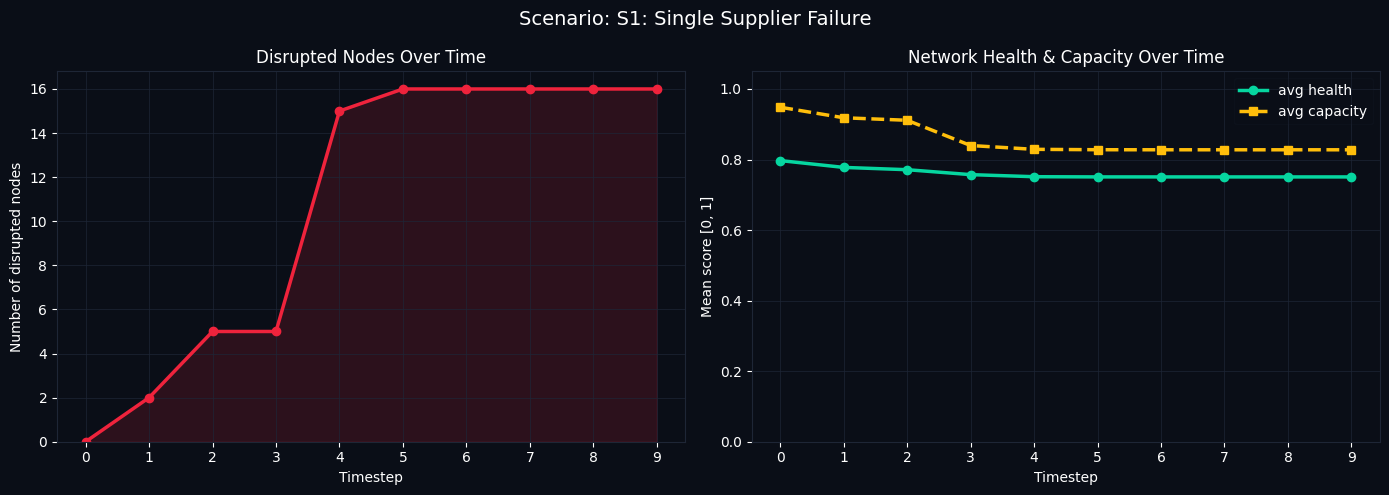

In [26]:
plot_timeseries(
    hist_s1,
    'S1: Single Supplier Failure',
    save_path=RESULTS_DIR / 'sim_s1_single_supplier_timeseries.png',
)

Saved -> c:\Users\hamza\OneDrive\Documents\MASTER THESIS\DTNet\Prototype\results\sim_s1_single_supplier_graph.png


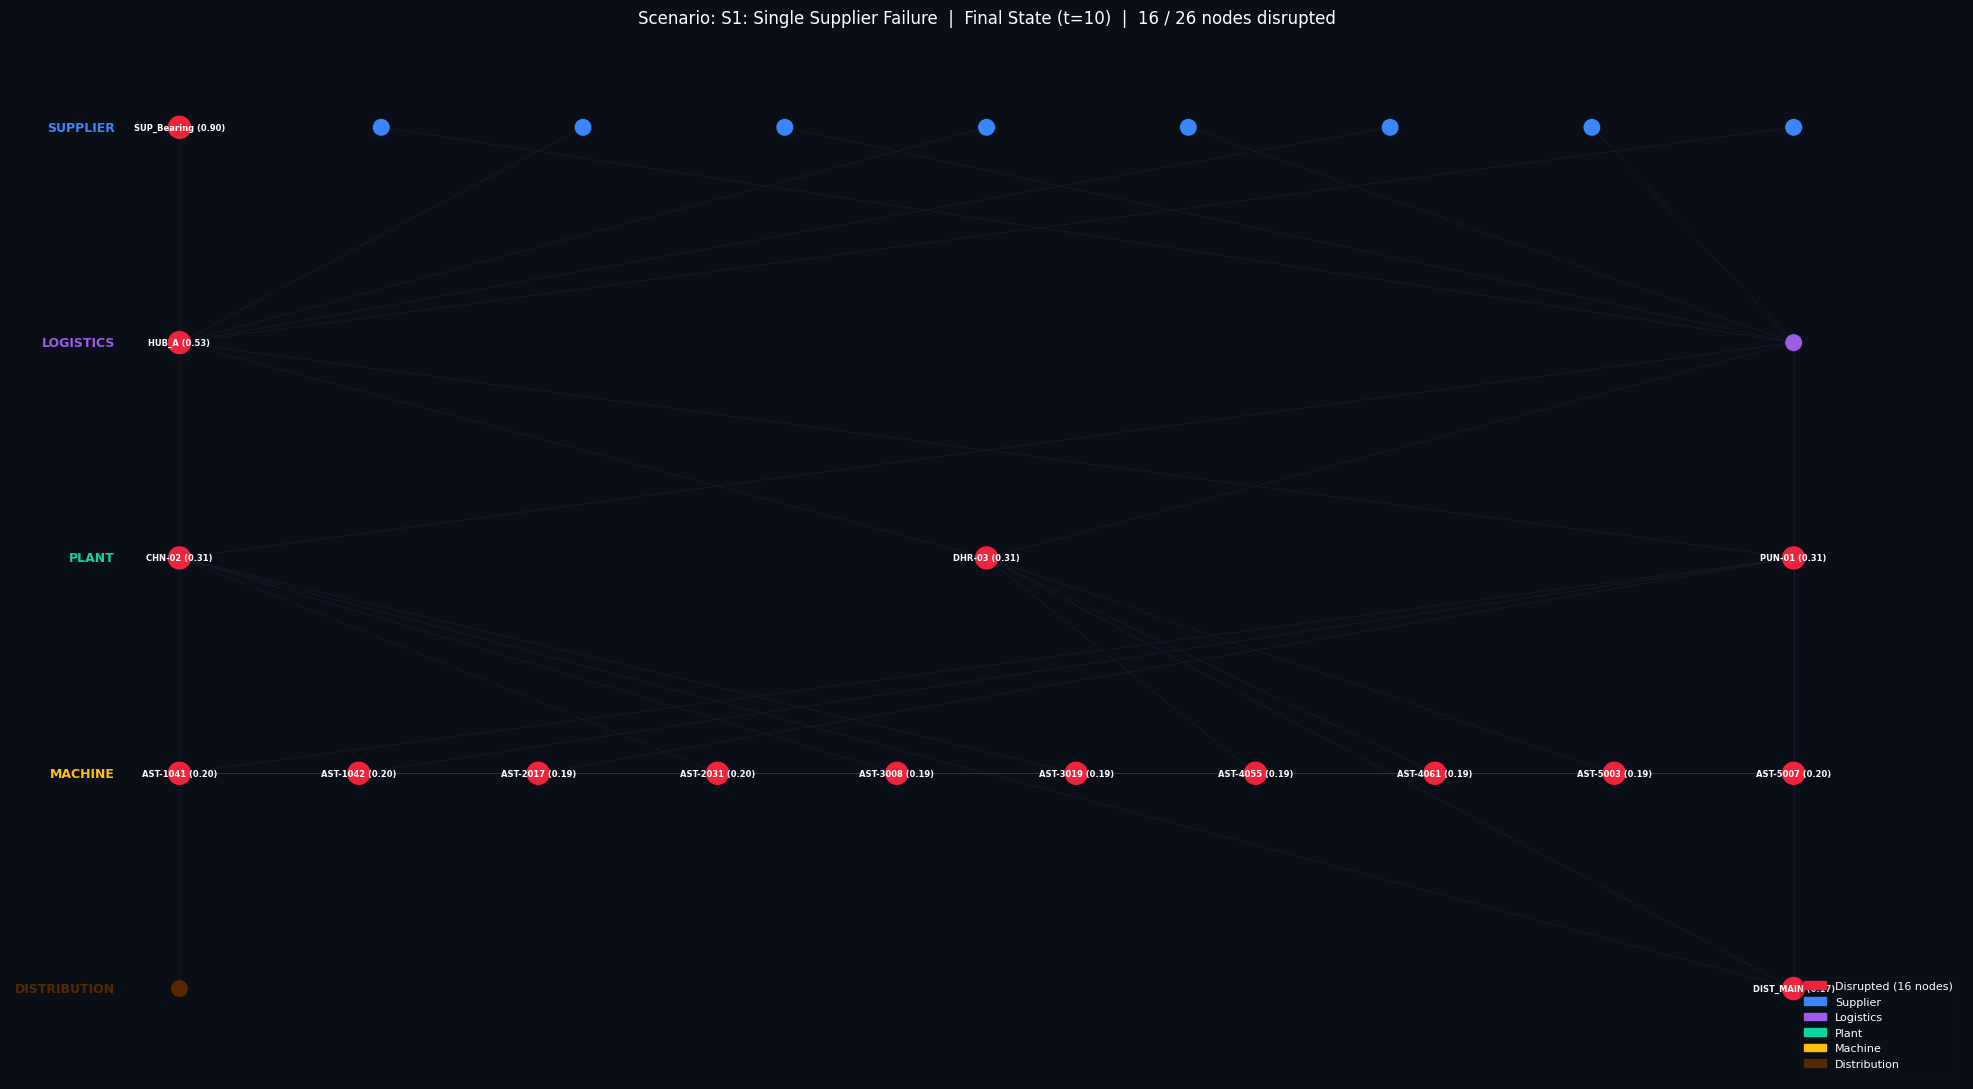

In [27]:
plot_graph_state(
    G, hist_s1, 'S1: Single Supplier Failure', pos,
    save_path=RESULTS_DIR / 'sim_s1_single_supplier_graph.png',
)

---
## 4. Scenario 2 â€” Logistics Hub Bottleneck

**What it tests (RQ1, RQ2):** A logistics hub (`HUB_A`) is partially congested at
severity 0.7. Because hubs sit between *many* suppliers and *many* plants, the blast
radius is wider than a single-supplier failure even at lower severity.

**Why interesting for the thesis:** Tests whether the GNN can detect that mid-chain
position amplifies impact independently of raw severity. A hub disruption at 0.7 may
disrupt more nodes than a supplier failure at 0.9 â€” this structural asymmetry is
exactly what graph-aware models should capture and isolated twins cannot.

In [28]:
# â”€â”€ HUB_A is the primary logistics hub in the topology â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
hub_id     = logistics_nodes[0]   # HUB_A
initial_s2 = logistics_bottleneck(G, hub_id, severity=0.7)

print(f'Disruption injected: {initial_s2}')
hist_s2 = run_scenario(G, initial_s2)
all_histories['S2: Logistics Hub'] = hist_s2

print_propagation(hist_s2, 'S2: Logistics Hub Bottleneck', initial_s2)

Disruption injected: {'HUB_A': 0.7}
  SCENARIO : S2: Logistics Hub Bottleneck
  Injected : {'HUB_A': 0.7}
  t= 0  newly=CHN-02(sev=0.00), DHR-03(sev=0.00), PUN-01(sev=0.00)
        total_disrupted=  0  health=0.785  capacity=0.931
  t= 1  newly=AST-1041(sev=0.00), AST-1042(sev=0.00), AST-2017(sev=0.00), AST-2031(sev=0.00), AST-3008(sev=0.00), AST-3019(sev=0.00), AST-4055(sev=0.00), AST-4061(sev=0.00), AST-5003(sev=0.00), AST-5007(sev=0.00), DIST_EXPORT(sev=0.00), DIST_MAIN(sev=0.00)
        total_disrupted=  4  health=0.755  capacity=0.824
  t= 2  newly=none
        total_disrupted= 16  health=0.749  capacity=0.806
  t= 3  newly=none
        total_disrupted= 16  health=0.748  capacity=0.803
  t= 4  newly=none
        total_disrupted= 16  health=0.748  capacity=0.803
  t= 5  newly=none
        total_disrupted= 16  health=0.748  capacity=0.803
  t= 6  newly=none
        total_disrupted= 16  health=0.748  capacity=0.803
  t= 7  newly=none
        total_disrupted= 16  health=0.748  capacit

Saved -> c:\Users\hamza\OneDrive\Documents\MASTER THESIS\DTNet\Prototype\results\sim_s2_logistics_bottleneck_timeseries.png


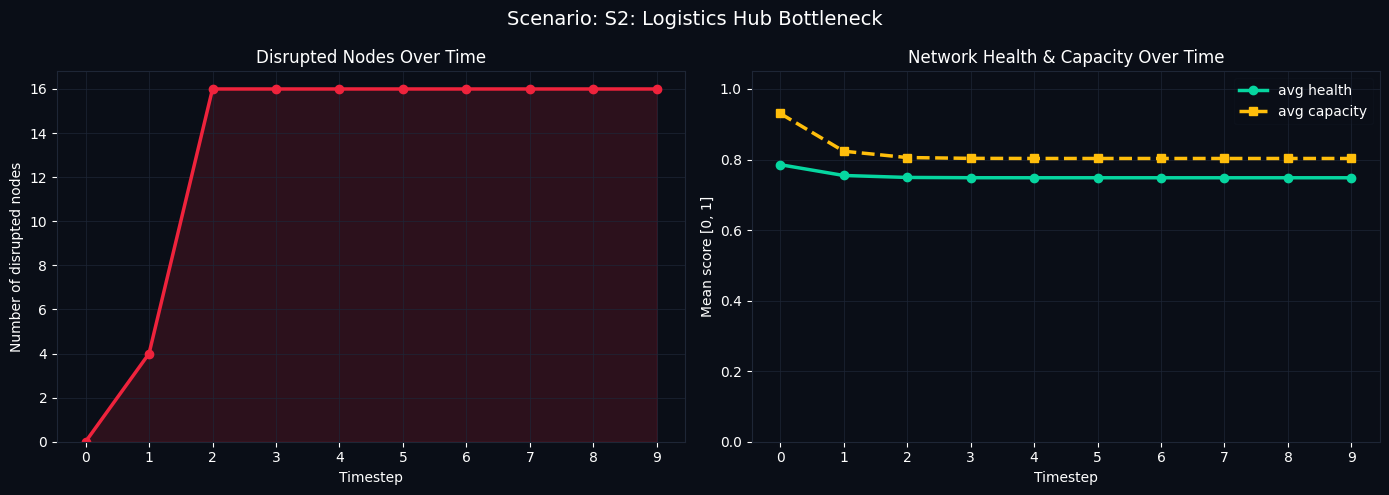

In [29]:
plot_timeseries(
    hist_s2,
    'S2: Logistics Hub Bottleneck',
    save_path=RESULTS_DIR / 'sim_s2_logistics_bottleneck_timeseries.png',
)

Saved -> c:\Users\hamza\OneDrive\Documents\MASTER THESIS\DTNet\Prototype\results\sim_s2_logistics_bottleneck_graph.png


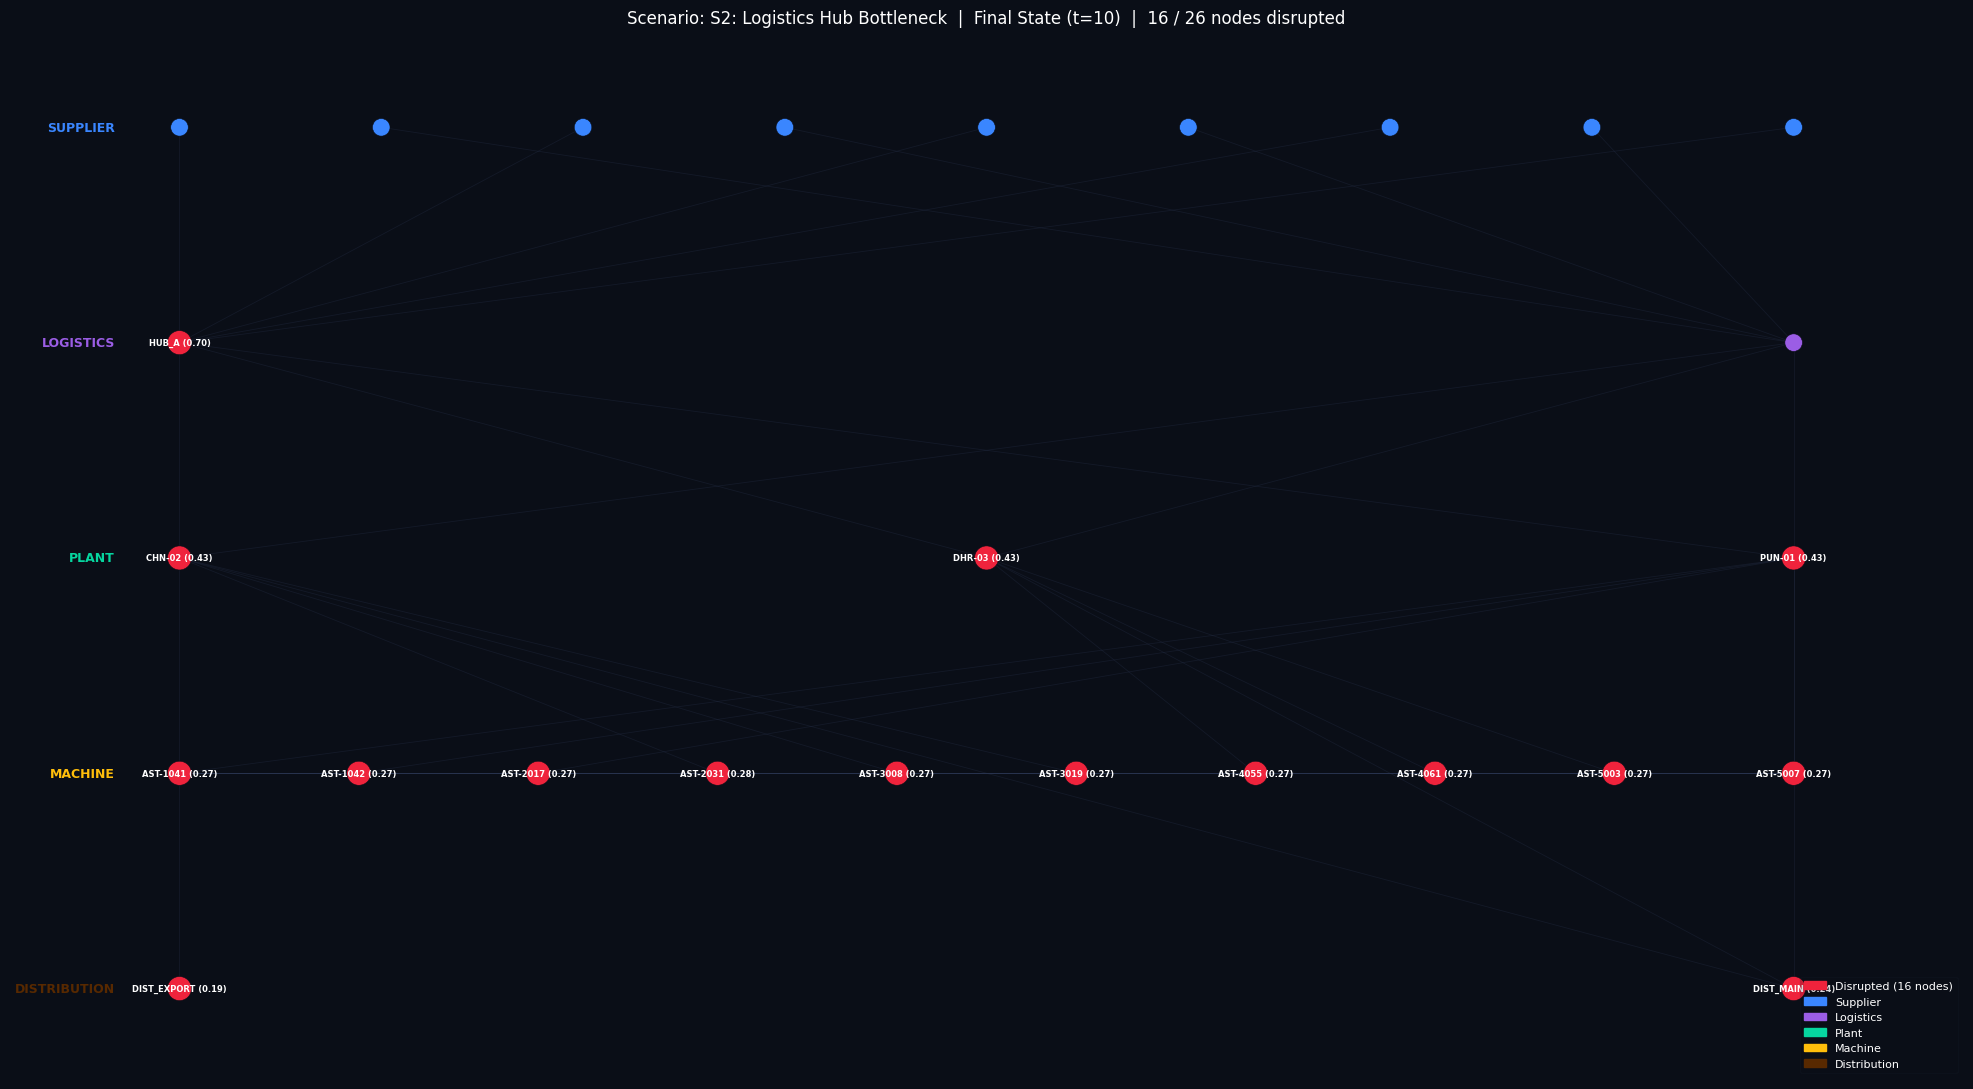

In [30]:
plot_graph_state(
    G, hist_s2, 'S2: Logistics Hub Bottleneck', pos,
    save_path=RESULTS_DIR / 'sim_s2_logistics_bottleneck_graph.png',
)

---
## 5. Scenario 3 â€” Multi-Supplier Cascade

**What it tests (RQ2):** Two suppliers fail simultaneously at severity 0.8.
All selected suppliers receive the same severity so structural position, not
asymmetric severity, drives the propagation difference.

**Why interesting for the thesis:** Modelling a semiconductor shortage or natural
disaster that hits multiple source nodes at once. Tests whether the GNN can detect
non-linear interaction effects â€” the combined disruption may exceed the sum of two
independent S1 scenarios because multiple supply paths to the same plant collapse
simultaneously, leaving it with no fallback.

In [31]:
initial_s3 = multi_supplier_cascade(G, n_suppliers=2, severity=0.8, seed=42)

print(f'Disruption injected: {initial_s3}')
hist_s3 = run_scenario(G, initial_s3)
all_histories['S3: Multi-Supplier'] = hist_s3

print_propagation(hist_s3, 'S3: Multi-Supplier Cascade', initial_s3)

Disruption injected: {np.str_('SUP_Bearing'): 0.8, np.str_('SUP_Lubrication'): 0.8}
  SCENARIO : S3: Multi-Supplier Cascade
  Injected : {np.str_('SUP_Bearing'): 0.8, np.str_('SUP_Lubrication'): 0.8}
  t= 0  newly=HUB_A(sev=0.00)
        total_disrupted=  0  health=0.775  capacity=0.923
  t= 1  newly=CHN-02(sev=0.00), DHR-03(sev=0.00), PUN-01(sev=0.00)
        total_disrupted=  3  health=0.758  capacity=0.897
  t= 2  newly=none
        total_disrupted=  6  health=0.753  capacity=0.891
  t= 3  newly=AST-1041(sev=0.00), AST-1042(sev=0.00), AST-2017(sev=0.00), AST-2031(sev=0.00), AST-3008(sev=0.00), AST-3019(sev=0.00), AST-4055(sev=0.00), AST-4061(sev=0.00), AST-5003(sev=0.00), AST-5007(sev=0.00)
        total_disrupted=  6  health=0.741  capacity=0.830
  t= 4  newly=none
        total_disrupted= 16  health=0.740  capacity=0.826
  t= 5  newly=none
        total_disrupted= 16  health=0.740  capacity=0.826
  t= 6  newly=none
        total_disrupted= 16  health=0.740  capacity=0.826
  t= 7  

Saved -> c:\Users\hamza\OneDrive\Documents\MASTER THESIS\DTNet\Prototype\results\sim_s3_multi_supplier_timeseries.png


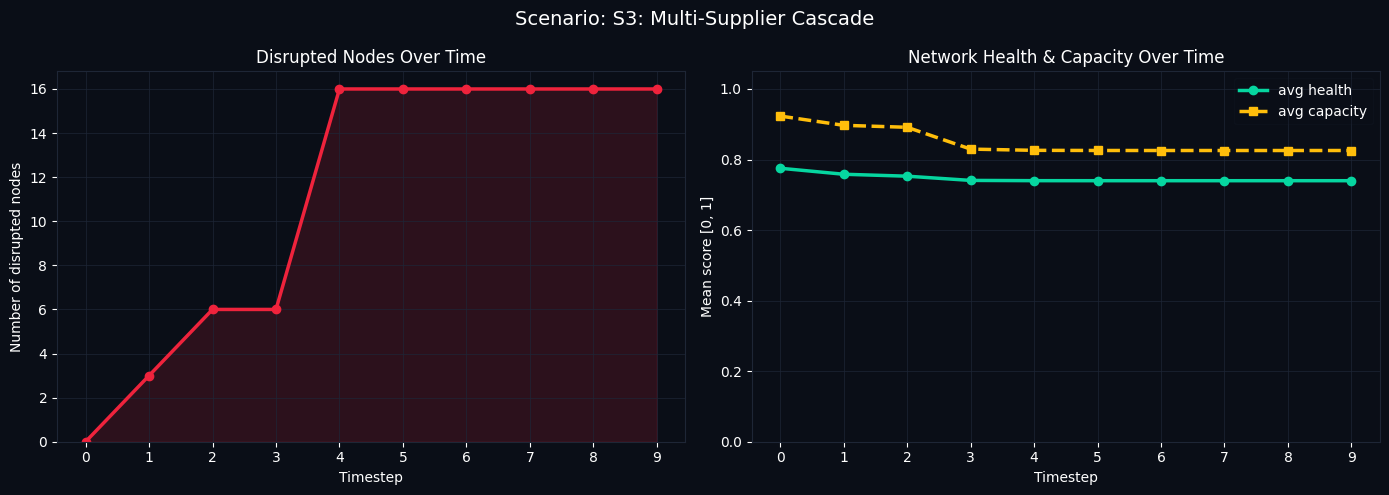

In [32]:
plot_timeseries(
    hist_s3,
    'S3: Multi-Supplier Cascade',
    save_path=RESULTS_DIR / 'sim_s3_multi_supplier_timeseries.png',
)

Saved -> c:\Users\hamza\OneDrive\Documents\MASTER THESIS\DTNet\Prototype\results\sim_s3_multi_supplier_graph.png


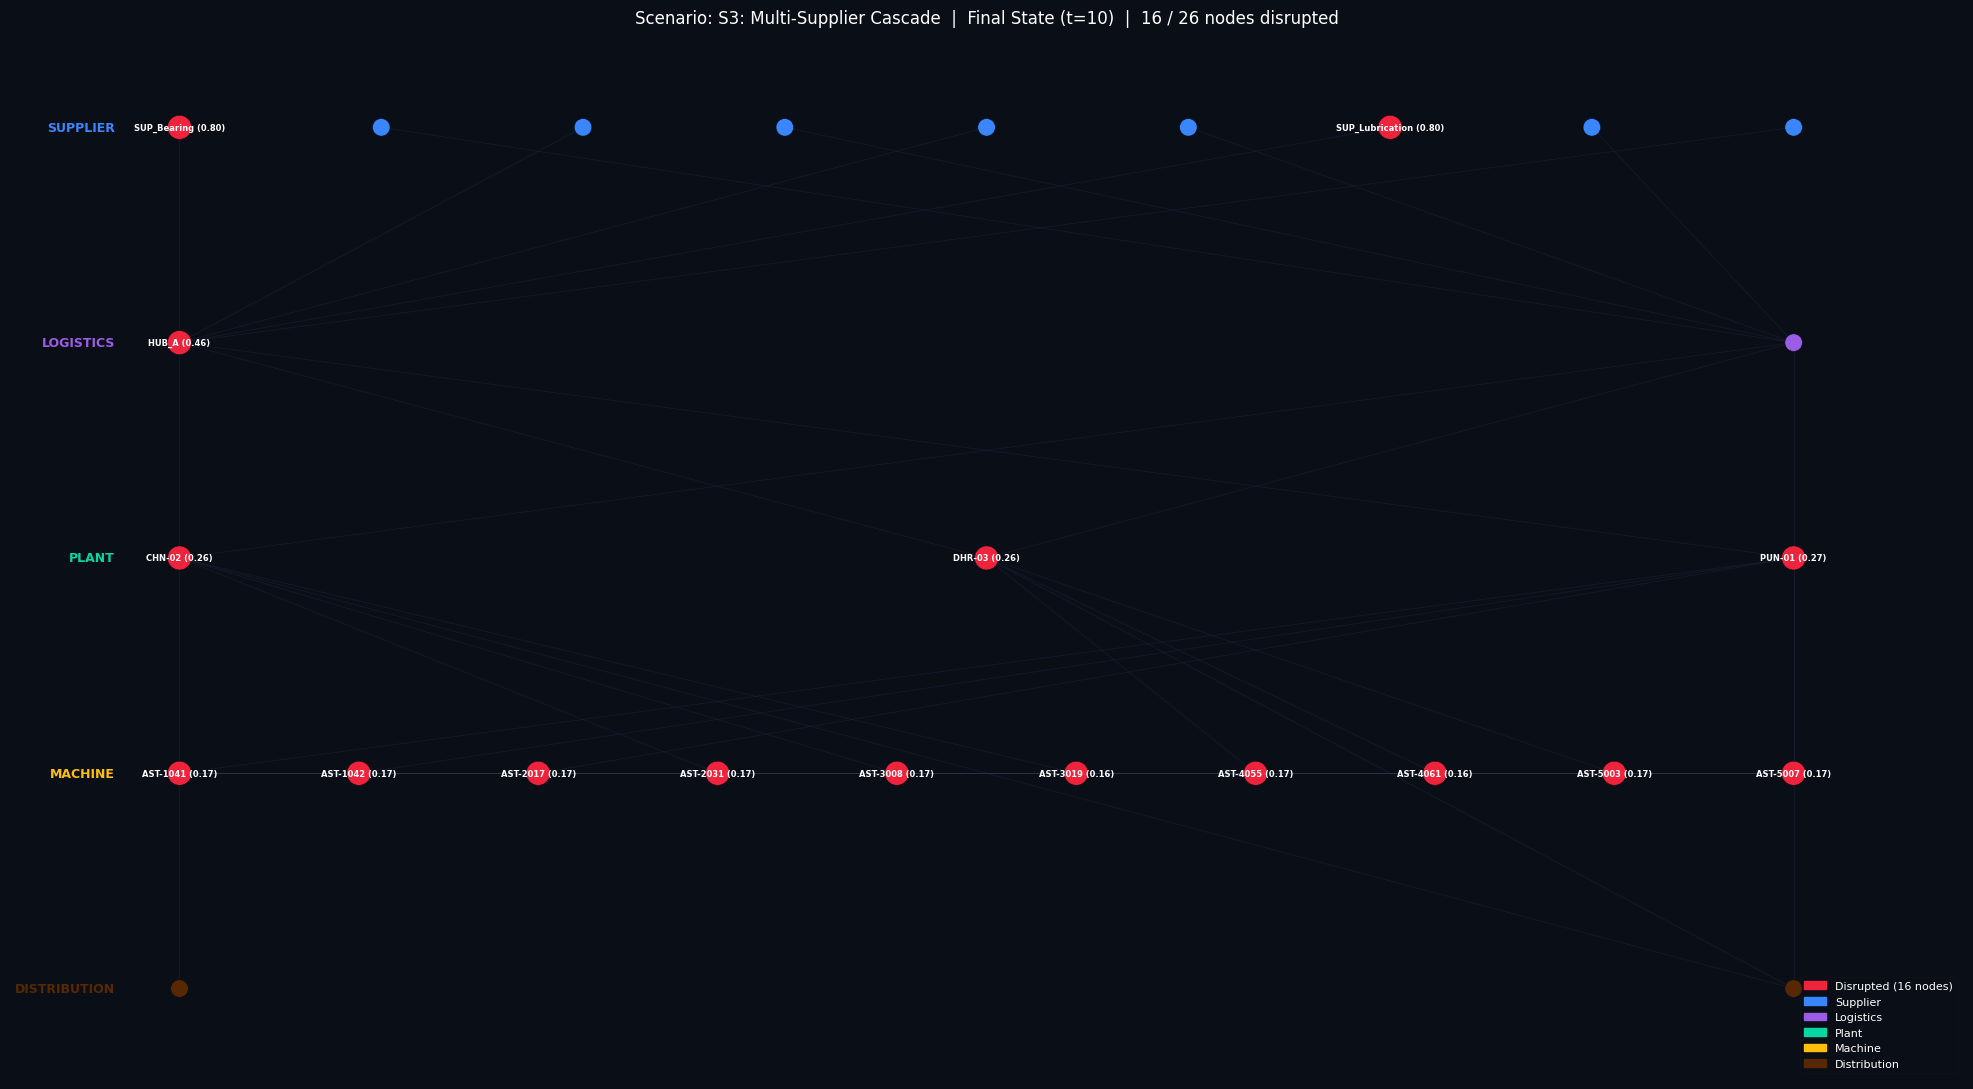

In [33]:
plot_graph_state(
    G, hist_s3, 'S3: Multi-Supplier Cascade', pos,
    save_path=RESULTS_DIR / 'sim_s3_multi_supplier_graph.png',
)

---
## 6. Scenario 4 â€” Targeted Attack (Highest Betweenness)

**What it tests (RQ3):** The single node with the highest betweenness centrality is
attacked at severity 0.9. Betweenness measures how many shortest paths in the graph
pass through a node â€” high-betweenness nodes are structural bottlenecks whose removal
fragments the maximum number of flow paths.

**Why interesting for the thesis:** This is the adversarial worst-case for RQ3.
The key question is: does the GNN, trained on simulation data, assign high vulnerability
scores to high-centrality nodes *before* any disruption occurs â€” enabling proactive
risk ranking? It also provides the worst-case baseline for the
isolated-vs-networked comparison (isolated twins are blind to their own centrality).

In [34]:
initial_s4 = targeted_attack(G, strategy='highest_betweenness', severity=0.9)

target_node = list(initial_s4.keys())[0]
target_layer = G.nodes[target_node].get('layer', 'unknown')
print(f'Target node : {target_node}  [layer={target_layer}]')
print(f'Disruption injected: {initial_s4}')

hist_s4 = run_scenario(G, initial_s4)
all_histories['S4: Targeted Attack'] = hist_s4

print_propagation(hist_s4, 'S4: Targeted Attack (highest betweenness)', initial_s4)

Target node : HUB_A  [layer=logistics]
Disruption injected: {'HUB_A': 0.9}
  SCENARIO : S4: Targeted Attack (highest betweenness)
  Injected : {'HUB_A': 0.9}
  t= 0  newly=CHN-02(sev=0.00), DHR-03(sev=0.00), PUN-01(sev=0.00)
        total_disrupted=  0  health=0.772  capacity=0.911
  t= 1  newly=AST-1041(sev=0.00), AST-1042(sev=0.00), AST-2017(sev=0.00), AST-2031(sev=0.00), AST-3008(sev=0.00), AST-3019(sev=0.00), AST-4055(sev=0.00), AST-4061(sev=0.00), AST-5003(sev=0.00), AST-5007(sev=0.00), DIST_EXPORT(sev=0.00), DIST_MAIN(sev=0.00)
        total_disrupted=  4  health=0.729  capacity=0.771
  t= 2  newly=none
        total_disrupted= 16  health=0.720  capacity=0.742
  t= 3  newly=none
        total_disrupted= 16  health=0.718  capacity=0.736
  t= 4  newly=none
        total_disrupted= 16  health=0.718  capacity=0.735
  t= 5  newly=none
        total_disrupted= 16  health=0.718  capacity=0.735
  t= 6  newly=none
        total_disrupted= 16  health=0.718  capacity=0.735
  t= 7  newly=non

Saved -> c:\Users\hamza\OneDrive\Documents\MASTER THESIS\DTNet\Prototype\results\sim_s4_targeted_attack_timeseries.png


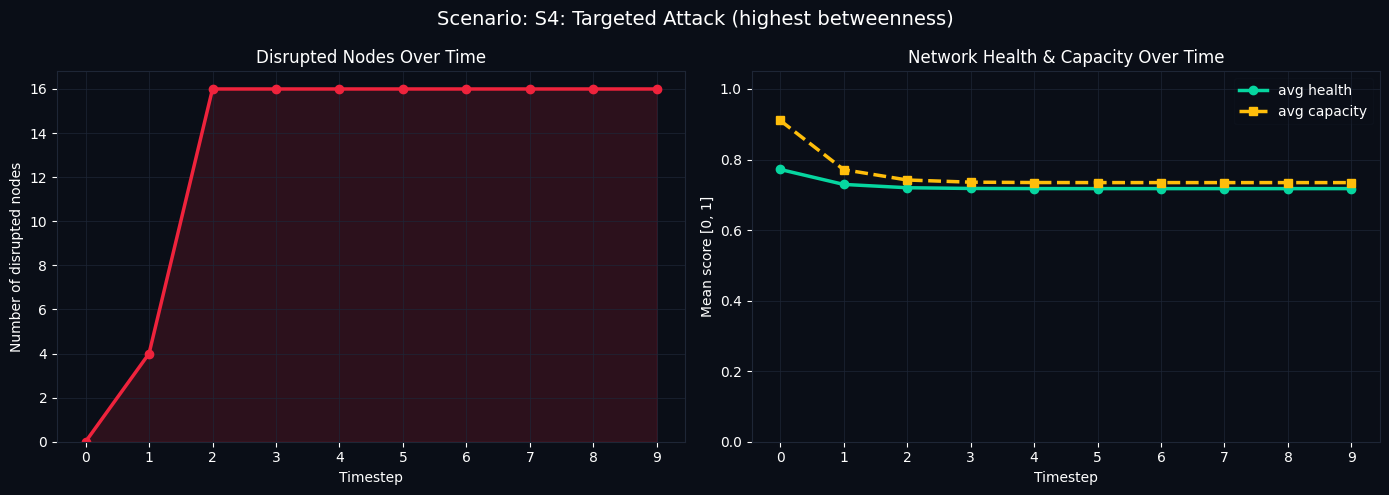

In [35]:
plot_timeseries(
    hist_s4,
    'S4: Targeted Attack (highest betweenness)',
    save_path=RESULTS_DIR / 'sim_s4_targeted_attack_timeseries.png',
)

Saved -> c:\Users\hamza\OneDrive\Documents\MASTER THESIS\DTNet\Prototype\results\sim_s4_targeted_attack_graph.png


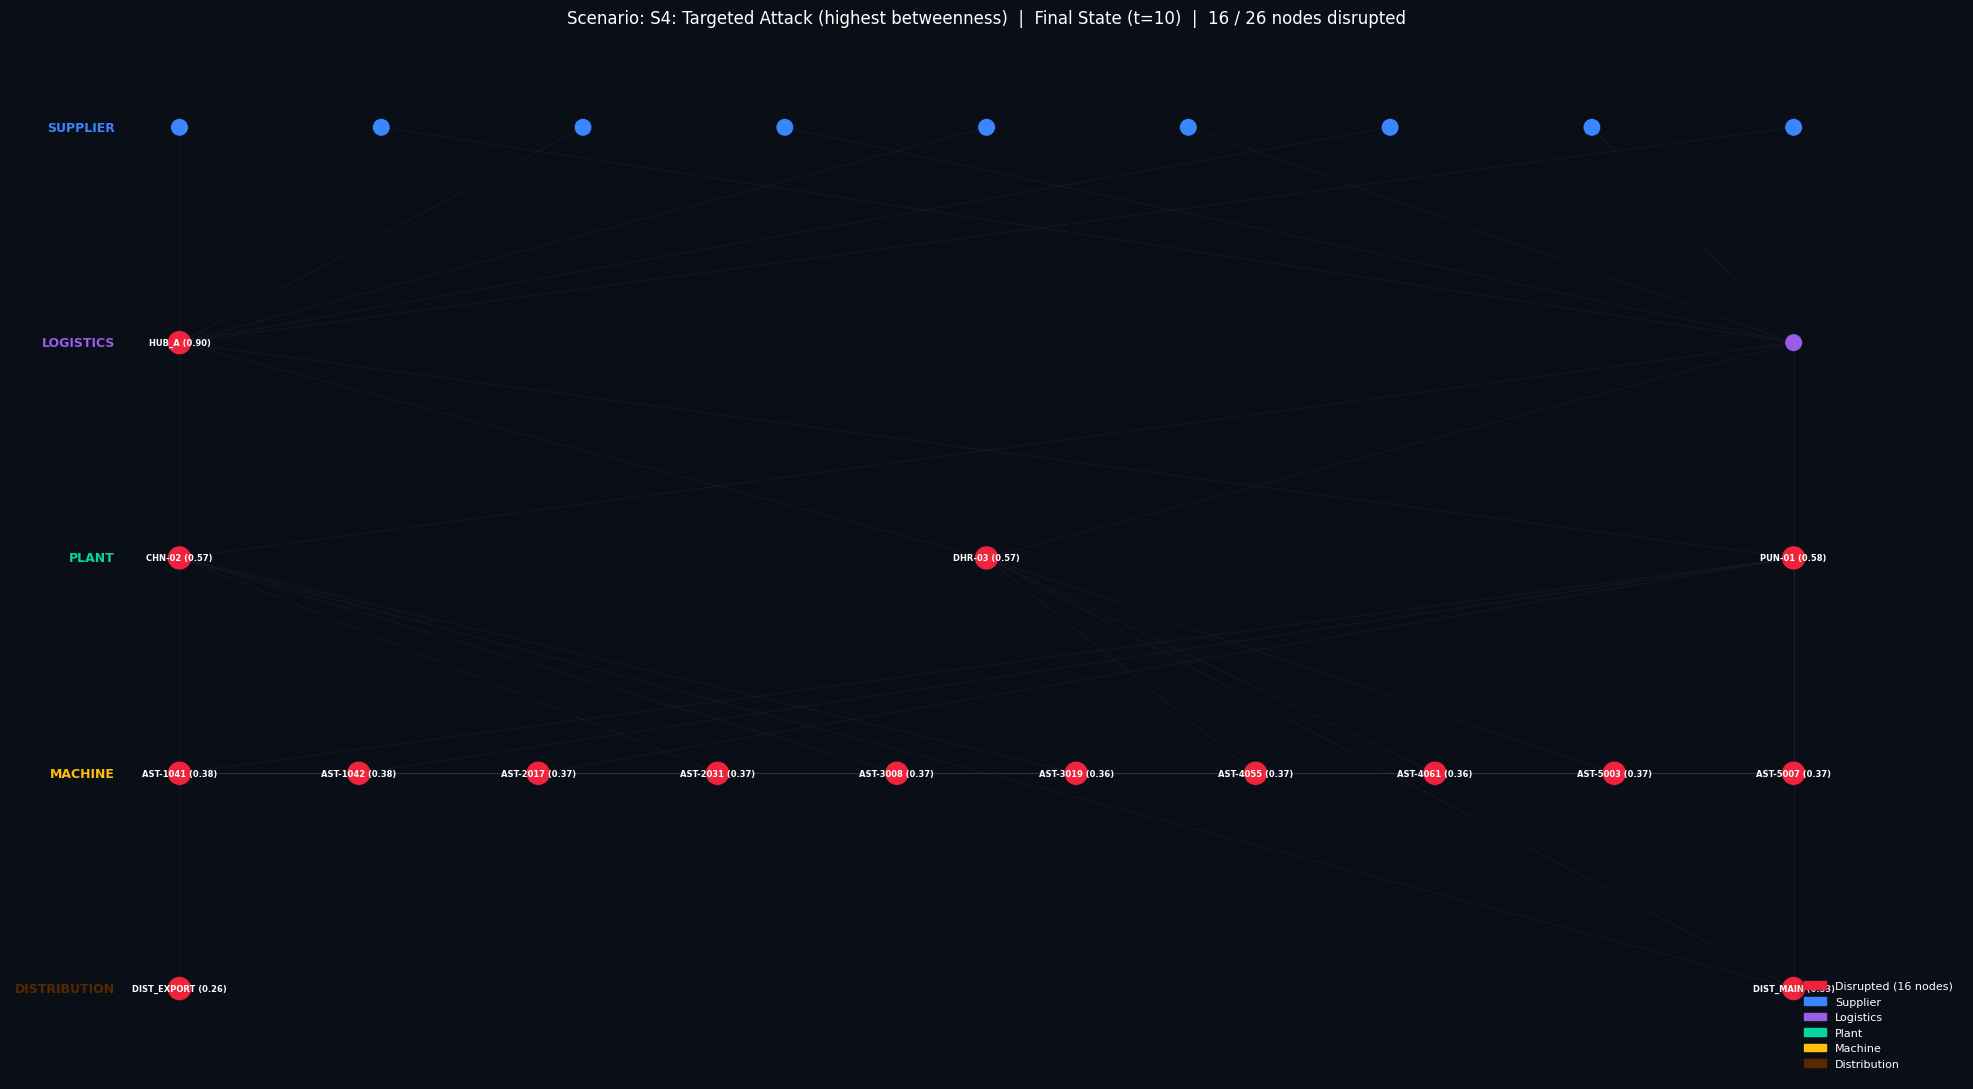

In [36]:
plot_graph_state(
    G, hist_s4, 'S4: Targeted Attack (highest betweenness)', pos,
    save_path=RESULTS_DIR / 'sim_s4_targeted_attack_graph.png',
)

---
## 7. Scenario 5 â€” Random Disruption

**What it tests (RQ1â€“3):** 3 random nodes are disrupted at severities sampled
uniformly from [0.3, 0.9]. This models the majority of real disruptions: neither
perfectly targeted nor naively upstream-only.

**Why interesting for the thesis:** Primary generator of GNN training diversity
(COMMON_MISTAKES #8). By varying `seed`, `n_nodes`, and the severity range across
thousands of calls, it produces the distributional breadth needed to prevent
overfitting. It also serves as the ecologically valid baseline â€” most events are
quasi-random in origin.

In [37]:
initial_s5 = random_disruption(G, n_nodes=3, min_severity=0.3, max_severity=0.9, seed=42)

print(f'Disruption injected: {initial_s5}')
hist_s5 = run_scenario(G, initial_s5)
all_histories['S5: Random'] = hist_s5

print_propagation(hist_s5, 'S5: Random Disruption', initial_s5)

Disruption injected: {np.str_('AST-2031'): 0.7184208174356184, np.str_('SUP_Drive Belt'): 0.3565064087325897, np.str_('AST-3019'): 0.8853734109820537}
  SCENARIO : S5: Random Disruption
  Injected : {np.str_('AST-2031'): 0.7184208174356184, np.str_('SUP_Drive Belt'): 0.3565064087325897, np.str_('AST-3019'): 0.8853734109820537}
  t= 0  newly=AST-1041(sev=0.00), AST-1042(sev=0.00), AST-2017(sev=0.00), AST-3008(sev=0.00), AST-4055(sev=0.00), AST-4061(sev=0.00), AST-5003(sev=0.00), AST-5007(sev=0.00), HUB_A(sev=0.00)
        total_disrupted=  0  health=0.791  capacity=0.806
  t= 1  newly=none
        total_disrupted= 12  health=0.790  capacity=0.802
  t= 2  newly=none
        total_disrupted= 12  health=0.790  capacity=0.802
  t= 3  newly=none
        total_disrupted= 12  health=0.790  capacity=0.802
  t= 4  newly=none
        total_disrupted= 12  health=0.790  capacity=0.802
  t= 5  newly=none
        total_disrupted= 12  health=0.790  capacity=0.802
  t= 6  newly=none
        total_disru

Saved -> c:\Users\hamza\OneDrive\Documents\MASTER THESIS\DTNet\Prototype\results\sim_s5_random_disruption_timeseries.png


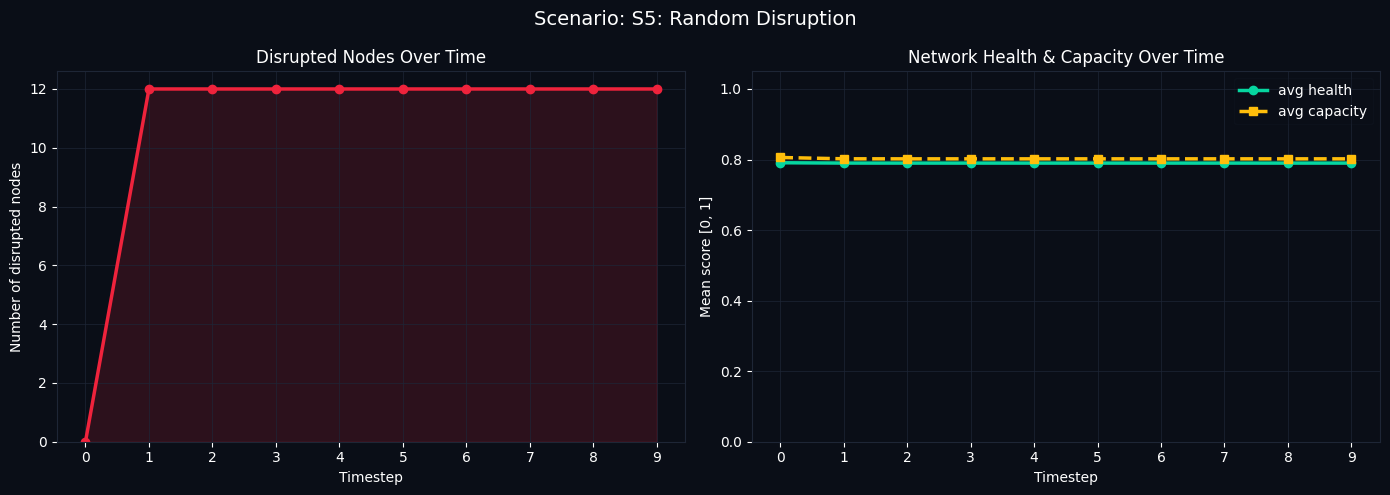

In [38]:
plot_timeseries(
    hist_s5,
    'S5: Random Disruption',
    save_path=RESULTS_DIR / 'sim_s5_random_disruption_timeseries.png',
)

Saved -> c:\Users\hamza\OneDrive\Documents\MASTER THESIS\DTNet\Prototype\results\sim_s5_random_disruption_graph.png


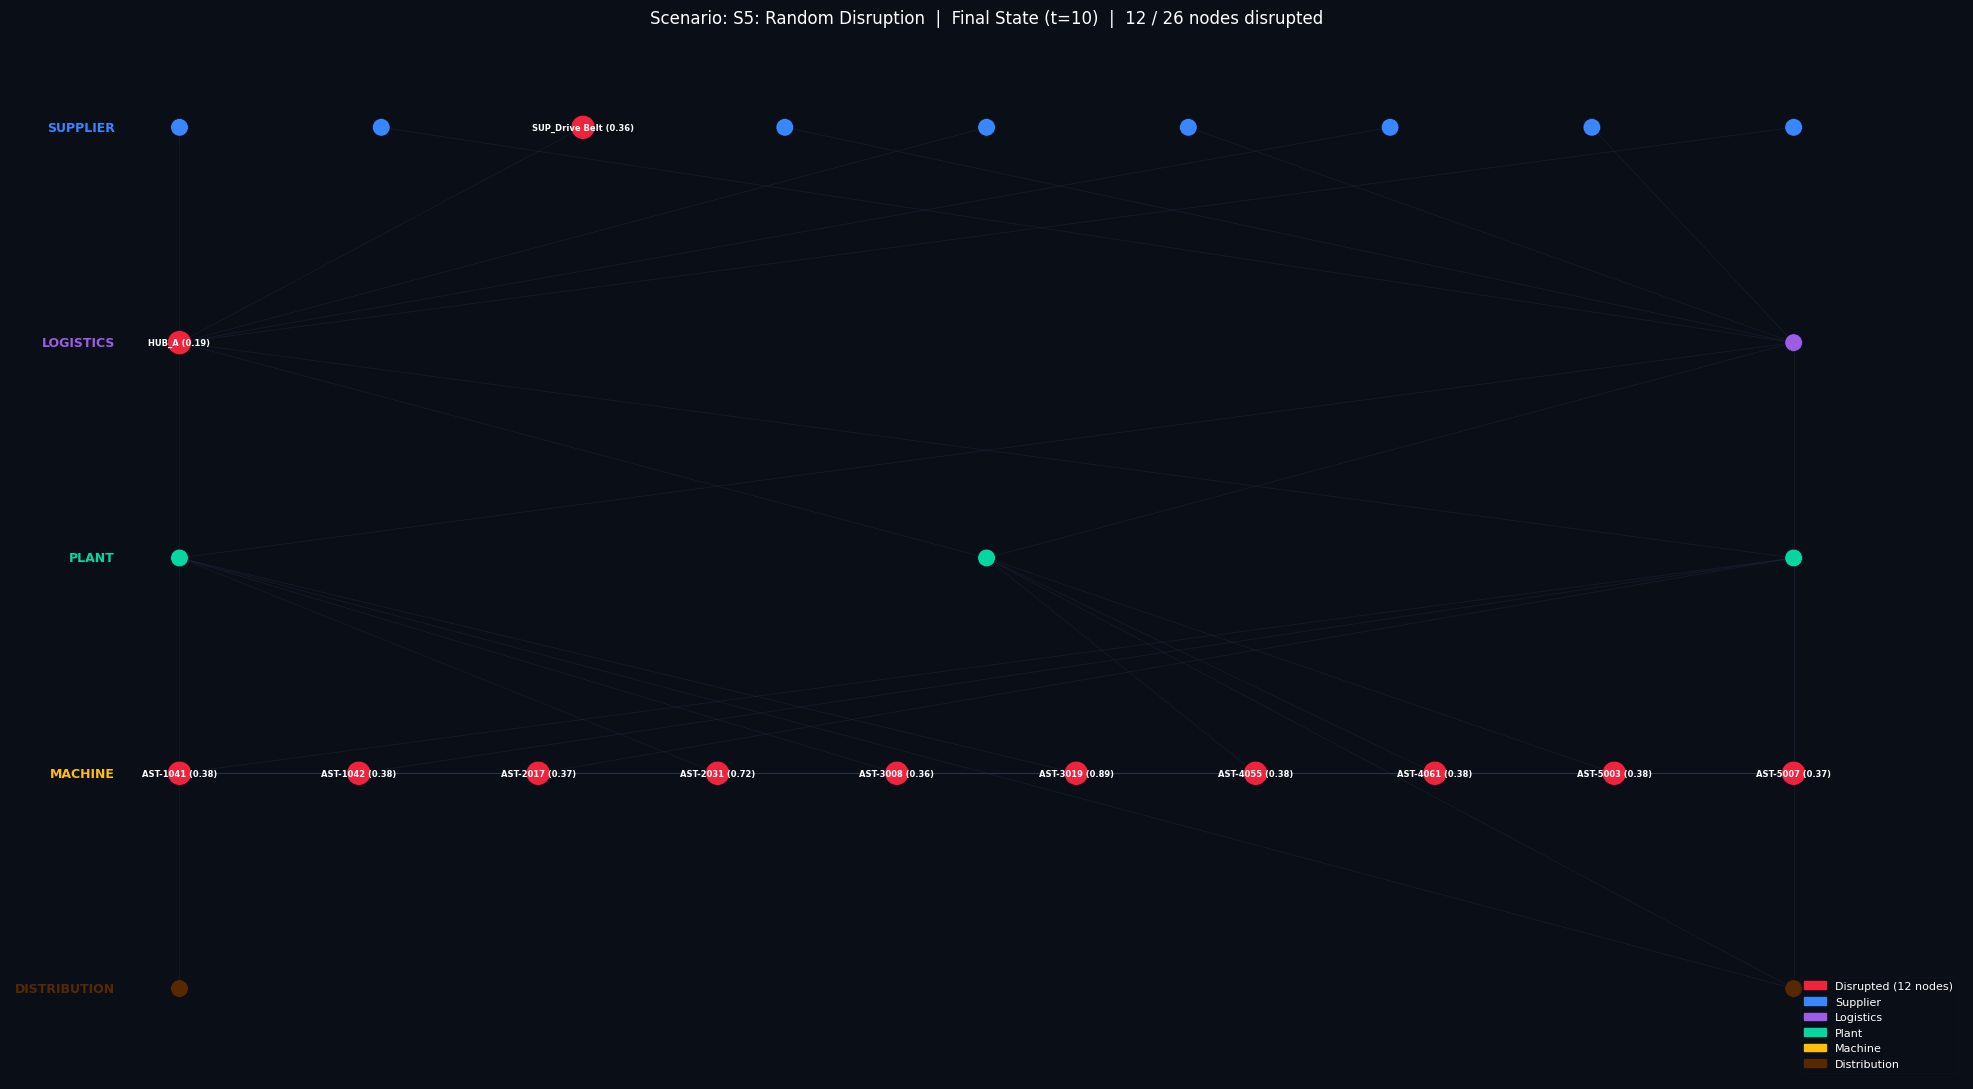

In [39]:
plot_graph_state(
    G, hist_s5, 'S5: Random Disruption', pos,
    save_path=RESULTS_DIR / 'sim_s5_random_disruption_graph.png',
)

---
## 8. Comparison â€” Which Scenario Causes the Most Damage?

We compare all 5 scenarios on three metrics:
- **Final disrupted nodes** â€” how many nodes are disrupted after 10 steps
- **Minimum network health** â€” the lowest average health score reached at any step
- **Final capacity** â€” remaining operational capacity at the end

**Expected result:** The targeted attack (S4) typically causes the most damage because
it destroys the node through which the most flow paths pass. A high-betweenness node
often sits at the intersection of multiple supply chains â€” its failure simultaneously
cuts off groups of downstream nodes that had no disruption of their own predecessors.
The logistics hub (S2) may rival it because hubs route cross-chain flows; the
multi-supplier scenario (S3) may cause more *initial* disruptions but less cascading
because suppliers are at the periphery of the graph (low betweenness, few predecessors
to propagate to).

In [40]:
# â”€â”€ summary statistics table â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
summary_rows = []
for name, hist in all_histories.items():
    final     = hist[-1]
    min_health = min(r['network_health'] for r in hist)
    max_disrupt = max(len(r['total_disrupted']) for r in hist)
    summary_rows.append({
        'Scenario':            name,
        'Initial seeds':       len([h for h in all_histories if h == name]),
        'Peak disrupted':      max_disrupt,
        'Final disrupted':     len(final['total_disrupted']),
        'Min network health':  round(min_health, 4),
        'Final health':        round(final['network_health'], 4),
        'Final capacity':      round(final['total_capacity'], 4),
    })

df_cmp = pd.DataFrame(summary_rows).set_index('Scenario')
print(df_cmp.to_string())

                     Initial seeds  Peak disrupted  Final disrupted  Min network health  Final health  Final capacity
Scenario                                                                                                             
S1: Single Supplier              1              16               16              0.7507        0.7507          0.8276
S2: Logistics Hub                1              16               16              0.7483        0.7483          0.8030
S3: Multi-Supplier               1              16               16              0.7400        0.7400          0.8256
S4: Targeted Attack              1              16               16              0.7175        0.7175          0.7346
S5: Random                       1              12               12              0.7899        0.7899          0.8019


Saved -> c:\Users\hamza\OneDrive\Documents\MASTER THESIS\DTNet\Prototype\results\sim_comparison.png


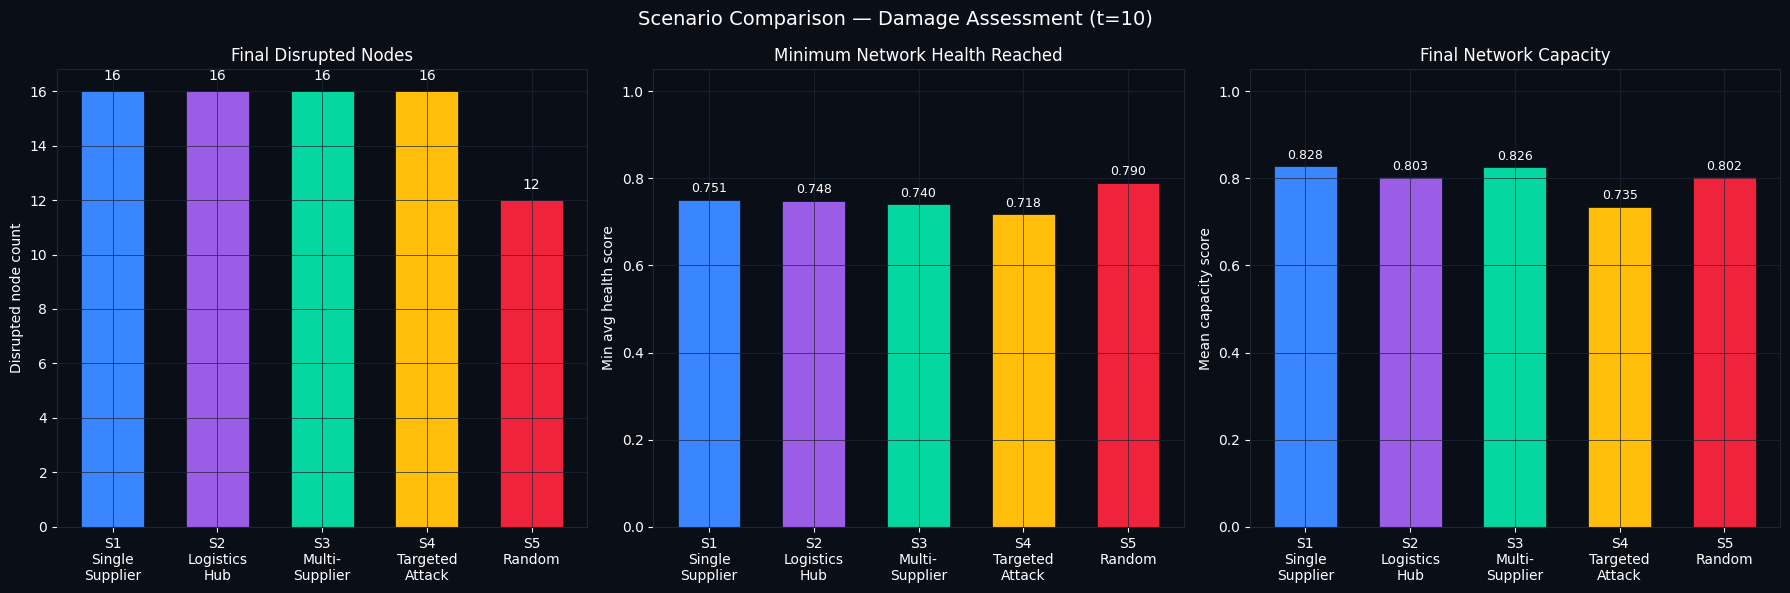

In [41]:
# â”€â”€ bar charts: final disrupted count and minimum health â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
names        = list(all_histories.keys())
bar_colors   = ['#3a86ff', '#9b5de5', '#06d6a0', '#ffbe0b', '#ef233c']
final_counts = [len(all_histories[n][-1]['total_disrupted']) for n in names]
min_healths  = [min(r['network_health'] for r in all_histories[n]) for n in names]
final_caps   = [all_histories[n][-1]['total_capacity'] for n in names]

short_names = ['S1\nSingle\nSupplier', 'S2\nLogistics\nHub',
               'S3\nMulti-\nSupplier', 'S4\nTargeted\nAttack', 'S5\nRandom']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
apply_dark_theme(fig, axes)

# Panel 1 â€” final disrupted count
bars0 = axes[0].bar(short_names, final_counts, color=bar_colors,
                    edgecolor=BG_COLOR, linewidth=0.5, width=0.6)
axes[0].set_title('Final Disrupted Nodes', fontsize=12)
axes[0].set_ylabel('Disrupted node count')
axes[0].set_ylim(bottom=0)
for bar, val in zip(bars0, final_counts):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                 str(val), ha='center', va='bottom', color=TEXT_COLOR, fontsize=10)

# Panel 2 â€” minimum health
bars1 = axes[1].bar(short_names, min_healths, color=bar_colors,
                    edgecolor=BG_COLOR, linewidth=0.5, width=0.6)
axes[1].set_title('Minimum Network Health Reached', fontsize=12)
axes[1].set_ylabel('Min avg health score')
axes[1].set_ylim(0, 1.05)
for bar, val in zip(bars1, min_healths):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                 f'{val:.3f}', ha='center', va='bottom', color=TEXT_COLOR, fontsize=9)

# Panel 3 â€” final capacity
bars2 = axes[2].bar(short_names, final_caps, color=bar_colors,
                    edgecolor=BG_COLOR, linewidth=0.5, width=0.6)
axes[2].set_title('Final Network Capacity', fontsize=12)
axes[2].set_ylabel('Mean capacity score')
axes[2].set_ylim(0, 1.05)
for bar, val in zip(bars2, final_caps):
    axes[2].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                 f'{val:.3f}', ha='center', va='bottom', color=TEXT_COLOR, fontsize=9)

fig.suptitle('Scenario Comparison â€” Damage Assessment (t=10)', color=TEXT_COLOR, fontsize=14)
plt.tight_layout()
out_path = RESULTS_DIR / 'sim_comparison.png'
fig.savefig(out_path, dpi=200, bbox_inches='tight', facecolor=BG_COLOR)
print(f'Saved -> {out_path}')
plt.show()
plt.close(fig)

Saved -> c:\Users\hamza\OneDrive\Documents\MASTER THESIS\DTNet\Prototype\results\sim_all_scenarios_overlay.png


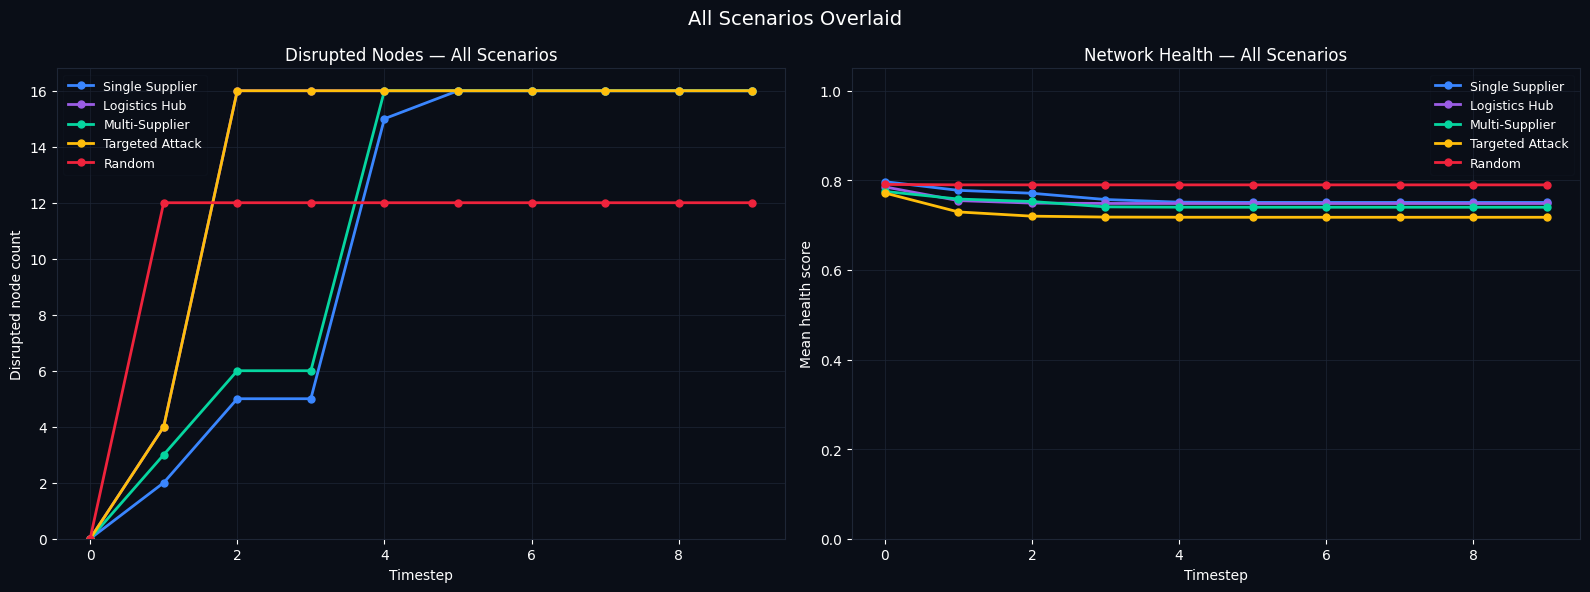

In [42]:
# â”€â”€ overlay health curves for all scenarios â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
apply_dark_theme(fig, axes)

for (name, hist), color in zip(all_histories.items(), bar_colors):
    timesteps   = [r['timestep'] for r in hist]
    num_disrupt = [len(r['total_disrupted']) for r in hist]
    health_vals = [r['network_health'] for r in hist]
    lbl = name.split(':')[1].strip()
    axes[0].plot(timesteps, num_disrupt, color=color, linewidth=2,
                 marker='o', markersize=5, label=lbl)
    axes[1].plot(timesteps, health_vals, color=color, linewidth=2,
                 marker='o', markersize=5, label=lbl)

axes[0].set_title('Disrupted Nodes â€” All Scenarios', fontsize=12)
axes[0].set_xlabel('Timestep')
axes[0].set_ylabel('Disrupted node count')
axes[0].set_ylim(bottom=0)
axes[0].legend(framealpha=0.15, labelcolor=TEXT_COLOR,
               facecolor=BG_COLOR, edgecolor=GRID_COLOR, fontsize=9)

axes[1].set_title('Network Health â€” All Scenarios', fontsize=12)
axes[1].set_xlabel('Timestep')
axes[1].set_ylabel('Mean health score')
axes[1].set_ylim(0, 1.05)
axes[1].legend(framealpha=0.15, labelcolor=TEXT_COLOR,
               facecolor=BG_COLOR, edgecolor=GRID_COLOR, fontsize=9)

fig.suptitle('All Scenarios Overlaid', color=TEXT_COLOR, fontsize=14)
plt.tight_layout()
out_path = RESULTS_DIR / 'sim_all_scenarios_overlay.png'
fig.savefig(out_path, dpi=200, bbox_inches='tight', facecolor=BG_COLOR)
print(f'Saved -> {out_path}')
plt.show()
plt.close(fig)

---
## Summary

### Interpretation

| Scenario | Why damage level is what it is |
|----------|--------------------------------|
| S1 Single Supplier | Damage is bounded by the fan-out of one supplier. Only plants that source exclusively from this supplier cascade further. |
| S2 Logistics Hub | Mid-chain node amplifies damage: the hub feeds multiple plants simultaneously, so even at lower severity the blast radius grows wider than S1. |
| S3 Multi-Supplier | Two simultaneous seed failures can collapse shared supply paths to a plant; interaction effects create more disruptions than two independent S1 runs would. |
| S4 Targeted Attack | Attacking the highest-betweenness node severs the maximum number of shortest paths at once. This is typically the most destructive scenario because the target node is the true structural bottleneck of the whole graph. |
| S5 Random | Outcome is highly seed-dependent. With seed=42 and n=3, the randomly chosen nodes may or may not be critical; this scenario occupies the median of the damage distribution. |

### Thesis implication
The damage ordering directly supports RQ3: **a GNN that has learned from these simulation
histories should be able to rank nodes by predicted vulnerability *before* any disruption
occurs**, matching the betweenness-centrality ordering seen in S4.
Isolated digital twins cannot replicate this ranking because they have no access to
structural graph features.

### Saved figures
- `results/sim_s1_single_supplier_timeseries.png`
- `results/sim_s1_single_supplier_graph.png`
- `results/sim_s2_logistics_bottleneck_timeseries.png`
- `results/sim_s2_logistics_bottleneck_graph.png`
- `results/sim_s3_multi_supplier_timeseries.png`
- `results/sim_s3_multi_supplier_graph.png`
- `results/sim_s4_targeted_attack_timeseries.png`
- `results/sim_s4_targeted_attack_graph.png`
- `results/sim_s5_random_disruption_timeseries.png`
- `results/sim_s5_random_disruption_graph.png`
- `results/sim_comparison.png`
- `results/sim_all_scenarios_overlay.png`

**Next:** `04_gnn_training.ipynb` â€” convert simulation histories to GNN training data.

In [ ]:
from src.simulation.data_generator import generate_simulation_data

# â”€â”€ chemin identique Ã  PKL_PATH dans notebook 04 â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
PKL_PATH = ROOT / 'data' / 'processed' / 'simulation_runs.pkl'
PKL_PATH.parent.mkdir(parents=True, exist_ok=True)

N_RUNS = 5_000

print(f'GÃ©nÃ©ration de {N_RUNS:,} runs â†’ {PKL_PATH}')
runs = generate_simulation_data(
    G,
    n_runs=N_RUNS,
    base_seed=0,
    output_path=PKL_PATH,
)

file_mb = PKL_PATH.stat().st_size / (1024 ** 2)
print(f'\nâ”€â”€ RÃ©sumÃ© â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€')
print(f'  Runs gÃ©nÃ©rÃ©s  : {len(runs):,}')
print(f'  Taille fichier: {file_mb:.1f} MB')
print(f'  Chemin        : {PKL_PATH}')
print(f'  NÅ“uds / run   : {len(runs[0]["node_order"])}')
print(f'  Features / nÅ“ud: {len(runs[0]["initial_features"][0])}')
print(f'  Fichier prÃªt pour notebook 04 âœ“')

In [ ]:
import pickle

# Cell 32 generates `runs` via generate_simulation_data() but saves to
# ROOT/notebooks/data/processed/ — the wrong path.  This cell re-saves
# the same in-memory `runs` variable to ROOT/data/processed/, which is
# the path dataset.py (PKL_PATH) and evaluate.py both expect.
# Run cell 32 first so `runs` is in memory before executing this cell.

CORRECT_PKL = ROOT / 'data' / 'processed' / 'simulation_runs.pkl'
CORRECT_PKL.parent.mkdir(parents=True, exist_ok=True)

with open(CORRECT_PKL, 'wb') as fh:
    pickle.dump(runs, fh, protocol=pickle.HIGHEST_PROTOCOL)

file_mb = CORRECT_PKL.stat().st_size / (1024 ** 2)
print(f'[notebook-03] Saved {len(runs):,} runs → {CORRECT_PKL}')
print(f'[notebook-03] Size           : {file_mb:.1f} MB')
print(f'[notebook-03] Keys per run   : {list(runs[0].keys())}')
print(f'[notebook-03] Nodes / run    : {len(runs[0]["node_order"])}')
print(f'[notebook-03] Features / node: {len(runs[0]["initial_features"][0])}')
print('[notebook-03] Ready for src/gnn/dataset.py  build_dataloaders() ✓')
